# Shor's Algorithm Explained with Python Simulation

**Author:** github.com/jfyo2

**Date:** March 2023

**Introduction** <br />
Shor's Algorithm is a quantum algorithm for factorising numbers, developed by American mathematician Peter Shor in 1994. What is special about this algorithm is that it can be used to factorise numbers in log-polynomial time, unlike classical algorithms which have exponential runtimes. This means that it should scale far better with large numbers than current algorithms, where runtime increases massively as numbers grow.

The significance of Shor's Algorithm for cryptography is that the ability to factor much larger primes much faster will mean that private keys used in RSA cryptography will be able to be calculated in reasonable timespans. It is estimated that currently, the 2048-bit RSA keys that we use (i.e. $2^{2048} \leq key < 2^{2049}$) would take 300 trillion years to factorise by a conventional computer [[1]](https://cryptoguiding-com.ngontinh24.com/articles/how-long-would-it-take-to-crack-rsa-2048), whilst a quantum computer with 4099 qubits (these are the quantum version of bits - we'll be hearing more about them soon!) would take just 10 seconds.

Currently, there is significant difficulty involved in running this algorithm. Qubits are by nature random and unstable, and a lot of work is required to error-correct them. As a result the largest number that has been factorised so far by Shor's Algorithm alone is just 21 [[2]](https://arxiv.org/abs/1111.4147). However, attempts to reduce the number of qubits required and offload some of the difficulty to classical computers, as well as other algorithmic improvements, show promise and much larger numbers such as 1,099,551,473,989 [[3]](https://www.newscientist.com/article/2227387-quantum-computer-sets-new-record-for-finding-prime-number-factors/) have been factorised using such methods.

In the future, it is considered likely that improvements in quantum computing will destroy the usefulness of RSA, and other encryption methods which rely on the Diffie-Hellman problem. As a result, research on post-quantum cryptography is beginning to take off, with the NIST (US government security organisation) calling for proposals for algorithms that could stand against quantum computers (without relying on the difficulty of e.g. the One-Time Pad). Some examples that have been proposed include lattice-based methods such as CRYSTALS-Kyber [[4]](https://csrc.nist.gov/Projects/post-quantum-cryptography/selected-algorithms-2022). As recently as December 2022, the NIST held its 4th conference on post-quantum cryptography, with draft standards to be hopefully released in 2024 [[5]](https://csrc.nist.gov/Projects/post-quantum-cryptography/workshops-and-timeline).

**How it works** <br />
There are two parts to Shor's Algorithm: a part that can run on classical computers, and a quantum _period finding routine_.

__Classical part__

Suppose we are given a number $N$ that we wish to factorise. Then the algorithm works as follows:
- Find some number $2\leq x<N$ which is coprime to $N$

- Calculate the _period_ of $x$ modulo $N$. In group theory terms, this means the order of $x\in (\mathbb{Z}/N\mathbb{Z})$ i.e. the smallest $p$ s.t. $x^p\equiv 1\space (mod\space N)$. (We use the word period because this is equivalent to finding the period of the function $f(t)=x^t \space(mod \space N)$.

- If the period $p$ is odd, go back to the start and try another $x$.

- Otherwise, if $p$ is even, we have that $x^p -1\equiv 0 \space (mod\space N)=>(x^{p/2}-1)(x^{p/2}+1)\equiv 0 \space (mod \space N)=>(x^{p/2}-1)(x^{p/2}+1)=kN$ for some integer k. These might not be factors of N (they might well be larger than N!) but certainly $gcd(x^{p/2}-1, N)$ and $gcd(x^{p/2}+1, N)$ are factors of N.

    In fact, not only are they factors of N, but they multiply to make N: $gcd(x^{p/2}-1, N)\times gcd(x^{p/2}+1, N)=N$ (the proof of this may be found below).

    For computational purposes, it might be more efficient to mod them first i.e. take $gcd(x^{p/2}-1 \space (mod\space N), N)$ and $gcd(x^{p/2}+1 \space (mod\space N), N)$, especially for large numbers - because we know that $gcd(a, b)=gcd(a\space (mod\space b), b)$. (This is the key point of the Euclidean Algorithm!)

- We can then apply Shor's algorithm repeatedly to these factors until all of our factors are primes (this can be checked using various primality tests e.g. Miller-Rabin)


__Issues__

There is one large point of failure for this algorithm:
- If our factors are 1 and N, they are clearly useless. Obviously all numbers have 1 and N as factors; this tells us nothing. This happens when $x^{p/2}\equiv \pm 1\space (mod \space N)$. All we can do when this happens is try again with a different random x.

There are two types of number that this algorithm does _not_ work on:
- Even numbers. If $N$ is even, then any coprime x we choose must be odd. So $x^{p/2}$ is odd, meaning both of $x^{p/2}\pm 1$ are even. So if $N$ is not a multiple of 4, one of them must be $0 \space (mod\space N)$, which is no good. If $N$ is a multiple of 4, apply the same argument to the factors - eventually we will get to a point where we have a factor that isn't a multiple of 4, so the algorithm will always fail.

    Try it! Comment out the section below that says
```python
if N % 2 == 0:
    return [2] + shor(N//2)
```
You will find that the algorithm never terminates.
- Powers i.e. numbers of the form $a^b$. For example, $64=8^2, 27=3^3, 243=3^5$. This is because we will always reach a point where we can only get out factors of 1 and N, so the algorithm will never terminate. More on this below.

    To test this, try commenting out the section that says
    ```python
    pc = powercheck(N)
    if pc[0]:
        return [i for i in shor(pc[1])   for j in range(0,pc[2])]
    ```
    Once again, the algorithm will never terminate.

**Proof that the multiples of the gcds is $N$**

Suppose that $N$ is an odd integer that we are trying to factorise. Then suppose that the prime factorisation of $N$ is $p_1^{a_1}p_2^{a_2}...p_n^{a_n}$.


Recall that

$(x^{p/2}-1)(x^{p/2}+1)=kN$


for some integer $k$. Let's suppose that $k$ has prime factorisation $2^{b}\times q_1^{b_1}q_2^{b_2}...q_m^{b_m}$ with $b$ possibly being 0 (if $k$ is odd). We'll see the reason for including this 2 in the prime factorisation later.


So we have

$(x^{p/2}-1)(x^{p/2}+1)=p_1^{a_1}...p_n^{a_n}\times 2^{b} \times q_1^{b_1}...q_m^{b_m}$

Note that the two factors on the LHS differ by 2. This means their highest common factor is at most 2.

Now $N$ is odd, so none of the $p_i$ s are 2 - only $k$ could have a factor of 2.
This means that none of the $p_i$ s are factors of both of $(x^{p/2}-1)$ and $(x^{p/2}+1)$.

So WLOG we can suppose that

$(x^{p/2}-1)=p_1^{a_1}...p_s^{a_s}\times 2^{b'} \times q_1^{b_1}...q_t^{b_t}$

$(x^{p/2}+1)=p_{s+1}^{a_{s+1}}...p_n^{a_n}\times 2^{b''} \times q_{t+1}^{b_{t+1}}...q_m^{b_m}$

for some $b'$ and $b''$, possibly 0, and some numbers s and t. That is, since the only factor they could possibly share is 2, all the indices of p and q will be different.

Now let's look at what happens when we take the gcd:

$gcd(x^{p/2}-1, N)=gcd(p_1^{a_1}...p_s^{a_s}\times 2^{b'} \times q_1^{b_1}...q_t^{b_t}, p_1^{a_1}...p_n^{a_n})=p_1^{a_1}...p_s^{a_s}$

$gcd(x^{p/2}+1, N)=gcd(p_{s+1}^{a_{s+1}}...p_n^{a_n}\times 2^{b''} \times q_{t+1}^{b_{t+1}}...q_m^{b_m}, p_1^{a_1}...p_n^{a_n})=p_{s+1}^{a_{s+1}}...p_n^{a_n}$

Hence, multiplying these together gives

$p_1^{a_1}...p_s^{a_s} \times p_{s+1}^{a_{s+1}}...p_n^{a_n} = N$

as required.





**Proof that Shor's algorithm does not work on powers**

We will prove this first for the case where $N=q^b$ where $q$ is a prime, not 2. (There is no need to consider even powers; the fact that it won't work for even numbers as noted above is sufficient.)

Recall that we have

$gcd(x^{p/2}-1, N)\times gcd(x^{p/2}+1, N)=N$

as proven above. That is,

$gcd(x^{p/2}-1, q^b)\times gcd(x^{p/2}+1, q^b)=q^b$

But since $q$ is a prime, the gcd of anything with $q^b$ can only be 1 or $q^m$ for some $m$. There are no other factors that they could share.

Now it is not possible for both of the two factors to be of the form $q^m$. This is because if they were, then that means that both $x^{p/2}-1$ and $x^{p/2}+1$ must be divisible by $q$. Since these two numbers differ by 2, and $q>2$, this is not possible.
Hence one of them must be 1 and the other $q^b$. That is, the factorisation has failed, since we got 1 and $N$.



Now for the general case:

Let $N$ have the form $a^b$. Then suppose $a$ has prime factorisation $p_1^{a_1}...p_n^{a_n}$ so that $N=p_1^{a_1 b}...p_n^{a_n b}$.

After repeatedly factorising $N$ multiple times, we will eventually end up with a situation where one of our factors is of the form $p_i^{a_i b}$. Why is this? Because we showed earlier that we will get

$gcd(x^{p/2}-1, N)=p_1^{a_1 b}...p_s^{a_s b}$ and $gcd(x^{p/2}+1, N)=p_{s+1}^{a_{s+1} b}...p_n^{a_n b}$ for some number $s$. (note we have added the $b$ here).

That is, every time we take these gcd factors, we are essentially splitting $N$ into two disjoint groups of prime factors (because the two gcds have to be coprime). So if we keep doing this, it follows by induction that we will eventually end up with some $p_i^{a_i b}$.

But we already proved that Shor's algorithm does not work for powers of primes. Hence once we reach this point, the algorithm will fail.



# The implementation

The code block below contains 4 functions:
- `shor(N)` - The algorithm. Finds a prime factorisation of $N$.
- `find_period(N, x)` - finds the period of $x \ mod \ N$ as described above. This is a simple implementation where we repeatedly multiply and take mod $N$ until we get 1. Later, we are going to look into how quantum computers can be used to speed this up.
- `powercheck(N)` - checks whether N is of the form $a^b$. This is done by checking whether $log_k (N)$ is an integer for every $k$ from 2 up to but not including $N$. If $N$ is not of the form $a^b$, it merely returns `[False]`. Otherwise, it returns `[True, a, b]`.
- `_log(x,base)` - calculates $\log$ of $x$ to the base $n$. Needed in `powercheck()`.

`shor(N)` is a recursive algorithm that repeatedly factorises until all factors are prime.
At the start of `shor(N)`, we first check whether $N$ is even or a power. If $N$ is even, add 2 to the list of factors, divide $N$ by 2, and try again. If $N$ is a power $a^b$, factorise $a$, and return each factor $b$ times.
Next repeatedly generate coprime $x$ until we find one with an even period.
Generate the two factors as described above. If they are 1 and $N$, try again. Otherwise, make a list called `primefactors`. Keep factorising the two factors again using Shor's algorithm until we reach a prime, then add it to `primefactors`. Keep doing this until every factor is prime, then return the list `primefactors`.

In [2]:
# By: jfyo2 on GitHub

import matplotlib.pyplot as plt
import random as r
import numpy as np
import sympy, time

In [3]:
# We wish to find a factorisation for N.
def shor(N):
    if sympy.isprime(N):
        print(N, "is a prime, so its only prime factor is itself.")
        return [N]
    print("factoring ", N)
    # The algorithm only works on odd numbers which are not powers, as described above

    # check whether N is even
    if N % 2 == 0:
        print(N, "is a multiple of 2, so divide by 2...")
        return [2] + shor(N//2)
    # check whether N is a power
    pc = powercheck(N)
    if pc[0]:
        # powercheck returns a tuple with 3 values:
        # pc[0] is true or false depending on whether N is a power
        # pc[1] and pc[2] tell us a and b (s.t. N=a^b) if it is
        # so the following code tells us to take a and factorise it, then list its factors out j times
        return [i for i in shor(pc[1])   for j in range(0,pc[2])]

    # We choose these values purely for convenience, so that we get onto the next while loop
    p = 1
    x = N

    # Keep trying until we find an even period
    while p % 2 == 1:

        # reason we initialise these values again every time is
        # to stop the following issue: Suppose we found a coprime integer but such
        # that the period was not even. Then we would never get onto the
        # next while loop (below) so would never update x, so the program would keep trying futilely to
        # get an even period from that same x forever. So we reset these to force
        # the program to generate a new x whenever we go back to the start of the loop.
        p = 1
        x = N

        # Generate a random number x coprime to N
        while sympy.gcd(N,x) != 1:
            x = r.randint(2, N)
            #print(x)

        p = find_period(N,x)
    print("Choice of coprime x: ", x ,"\nPeriod of x mod N: ", p)

    # Now we take the factors using the gcd as described above

    factors = [sympy.gcd(N, (x**(p//2)-1) % N), sympy.gcd(N, (x**(p//2)+1) % N)]
    print("factors: ", factors)

    # Now we just need to repeat until all factors are prime
    primefactors = []

    for i in range(0,len(factors)):
        f = factors[i]

        # redo if one of the factors is 1
        if f == 1:
            print("factors are 1 and N, so try again")
            return shor(N)

        # if we find a non-prime factor, factorise that by applying algorithm again
        elif sympy.isprime(f) == False:
            # We know (see below!) that shor(N) only returns prime factors, so we can just apply
            # shor again to f to get its prime factors
            f_factorised = shor(f)
            for j in range(0, len(f_factorised)):
                primefactors.append(f_factorised[j])

        # if f is prime, we can just add it to the list of primefactors
        else:
            primefactors.append(f)


    return primefactors



# Brute force method for finding the period. This is what the quantum period finding routine will replace.
def find_period(N, x):
    r       = 1
    product = x

    while product != 1:
        product = product * x % N
        r += 1

    return r


# Check whether N is a power (i.e. form a^b)
def powercheck(N):
    for i in range(2, N):
        # check whether N's logarithm is an integer
        if _log(N,i) % 1 < 10**(-8):                # use a tolerance because of floating point rounding errors
            # Return true, a and b where N=a^b
            return [True, i, round(_log(N,i))]
    return [False]


# Calculate log x to a given base
def _log(x, base):
    return np.log(x) / np.log(base)


shor(174)

factoring  174
174 is a multiple of 2, so divide by 2...
factoring  87
Choice of coprime x:  83 
Period of x mod N:  14
factors:  [29, 3]


[2, 29, 3]

# The Quantum Part

**Introduction: The basics of quantum computing** <br />
In classical computing, information is stored in binary bits - that is, as large arrays of 0s and 1s. Each bit is either 0 or 1, and cannot be anything else.

With quantum computing, we do not use bits, but _qubits_ - quantum bits. The special thing about quantum bits is that they do not have to be either 0 or 1, but they can be in a _superposition_ of 0 and 1. What does this mean? We can explain in linear algebra terms:

One bit can store either (0) or (1). That is, two possible states. So we'll use two dimensional vectors to represent them - specifically, we represent them using the standard basis.

$(0)=\begin{bmatrix} 1 \\ 0 \end{bmatrix}$ and $(1)=\begin{bmatrix} 0 \\ 1 \end{bmatrix}$


Then one _qubit_ can be in a state which is a linear combination of these two vectors:

$a\begin{bmatrix} 1 \\ 0 \end{bmatrix}+b\begin{bmatrix} 0 \\ 1 \end{bmatrix}$

We call this a _superposition_. Note: There is one restriction on the coefficients - we will get onto that later.

If we have two bits, we can store any of (00),(01),(10),(11). Four possibilities, so we will use the four-dimensional standard basis to represent them:

$(00)=\begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}$, $(01)=\begin{bmatrix} 0 \\ 1 \\ 0 \\ 0\end{bmatrix}$, $(10)=\begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \end{bmatrix}$, $(11)=\begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix}$

So our superposition is of the form:

$a\begin{bmatrix} 1 \\ 0 \\ 0 \\ 0 \end{bmatrix}+b\begin{bmatrix} 0 \\ 1 \\ 0 \\ 0\end{bmatrix} +c\begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \end{bmatrix}+d\begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix}$

In general, for a register of $n$ qubits, we have a basis of dimension $2^n$.

However, there is a catch. Though a register of $n$ qubits can be in these superpositions, when we actually go to measure the state of the register to use it for calculations, we will only be able to get out one of the states, with a certain probability. This probability is in fact given by the square of the coefficient of the state in the superposition. This is known as _quantum wavefunction collapse_.

So for example, in our two qubit superposition, the probability of getting (00) equals $a^2$, the probability of getting (01) equals $b^2$, and so on. (This is called the _Born Rule_.)

As mentioned previously, this puts one restriction on the coefficients - their squares must add up to 1. So in the one qubit case, we must have $a^2+b^2=1$, and in the two qubit case, we must have $a^2+b^2+c^2+d^2=1$.

That is, the superposition actually represents a probability density function. Why is this the case? Nobody really knows, and there are multiple different "interpretations" of quantum mechanics that postulate potential mechanisms by which this could occur. For example, two are the Copenhagen and Many-Worlds interpretations of quantum mechanics.



**An Analogy**

To clarify some of the ideas used in quantum computing, consider the following analogy.
Imagine that a register of $q$ qubits is a $2^q$ sided dice. Suppose the area of each face represents the probability of getting each number out (note that for consistency with the Born rule we could suppose each face is square and its side length is the coefficient of the basis). We can decide when we make the dice how large each side should be, and we can use functions to alter the sizes during the algorithm.

However, the dice is invisible, so the probabilities cannot just be read off at any given moment. This means that we might apply a function where we do not exactly know how it affects the probability - and this idea is used in the algorithm in the `modTransform()` function, as we will see below.

Furthermore when we toss the dice (observe the register), all of the faces that do not come up on top will vanish simultaneously and the face that came up will expand to have an area (probability) of 1. So the dice cannot be tossed multiple times to get out multiple outcomes; it can only be tossed once.


**Introduction**


The key insight of Shor's algorithm is that we can exploit certain properties of quantum computing to massively speed up finding the period of $x\ mod \ N$. This is the part that is very computationally-intensive for classical computers.

To clarify what we are doing: Recall that we have some $N$ that we want to factorise, and some $x$ that is coprime to it. We wish to find $p$ s.t. $x^p \equiv 1 \space (mod \space N)$.

Below are two code blocks. The first defines a class, `QReg` (quantum register) which represents a register of qubits with some functions that can act on them. These functions are what we will need to calculate the period. The second is a function `quantum_period()` for finding the period using this quantum register.

Because this code is of course running on a classical computer and not a quantum one, it is a simulation using probabilities. Therefore, we cannot actually do ultra-fast factorisation using this method. In fact, it will end up being far slower than the simple brute force algorithm that we used above, since we have to calculate all the probabilities manually instead of all the calculations being done in parallel by superposition. However, for instructive purposes, it is fine - though I would advise not trying to calculate periods for $N>40$, as it takes too long. (Since in reality, the largest number ever factorised purely by Shor's algorithm is 21, this isn't too bad!)



**How it works**

Let's consider the function $f(t)=x^t \space (mod \space N)$. This is a periodic function; the period of the function is the same as the order of $x$. The function for $N=15, x=7$ is shown below.


We begin by setting up a qubit register (call it register 1) of size $q$ such that $2^q\geq 2^N$. This is represented as an array of integers, size $2^q$, where the integer in the $n$th position is the probability of getting out $n-1$ when we observe the qubit (toss the dice).
When we first initialise this register, it will be uniformly distributed. So we initially have a probability of $1/q^2$ of measuring any number from it. (This is done by setting it up as `numpy.ones()` and then applying the function `normalise()` which just divides each entry in the array as the sum of all entries in the array, so that the sum is 1.)

We then set up a second register (register 2) where the $k$th entry is the probability that $k=f(t)$ for all possible $k$ (we check all $k$ in register 1). For example for $N=15, x=7$, the possible values of $x^i \space(mod \space N)$ are 1,4,7,13 (the probabilities of everything else will be 0). Register 2 and Register 1 are quantum-entangled - this will be important later.

The way we set up register 2 is by applying the function `modTransform()` to an array of `numpy.zeros()`. This function steps through each number i from 0 to $2^q-1$ in the first register, and calculates $k=f(i)$. It then adds the probability of getting i from the first register to the probability of getting $k$ in the second register. Once this is done, we apply `normalise()` so that the sum of the probabilities is 1.


**Analogy:** Let's suppose we have a periodic line of $2^q$ cars along a road of different colours. Though there are a variety of possible colours that the cars could be (say the manufacturer sells them in the colours of the rainbow), in reality not all of these actually show up. (This is equivalent to how whilst we could theoretically get out any number between 0 and $N-1$ inclusive from $f(t)$, for any given $x$ only specific values show up.)

So we set up two probability registers - one that tells us the probability of choosing any specific car, and a second one that tells us the probability of choosing a car of any of the possible colours.


Next we measure register 2 using `observe()`. As described above, this 'quantum collapses' the wavefunction by randomly picking a number based on the probabilities in the array, and then making the probability of getting that number 1, and the probability of everything else 0. Using the dice analogy, this is the part where we toss the dice and the faces disappear.

Actually, however, we do not care about the results of this observation. What we care about is that since the first register was quantum entangled with the second, it will be altered by this collapse so that only values of t where $f(t)={observed\space number}$ have non-zero probability.

**Analogy:** This is like measuring the colour register. Suppose we get blue. This then alters the uniform register so that we can only pick blue cars.

The reason why we do this is that now the period of non-zero values in register 1 is now the same as the period of $f(t)$. So now all we need to do is think of a way of extracting the period from the register.

A naive answer would be to measure many values from the register and find the smallest distance between two values; that is the period. But recall that after each value is measured, "the faces of the dice disappear". So we would need to set up the whole system again multiple times, repeating until we have gotten the same observed value many times so that we have enough information. This is clearly not a particularly good solution...


Instead we create a new register by applying a (discrete) Fourier transform to the values of the register, because this can be done without collapsing the function. This is implemented as `QFT()` (quantum Fourier transform).

The Fourier transform decomposes a mixture of periodic signals into its constituent frequences and amplitudes.

(note that $frequency=1/period$, so it is simple to go from this to the period).

Without going too much into detail as to why the Fourier transform works, it can be represented as putting all of the probabilities into a column vector and then multiplying by the matrix

${\frac {1}{\sqrt {2^q}}}{\begin{bmatrix}1&1&1&1&\cdots &1\\1&\omega &\omega ^{2}&\omega ^{3}&\cdots &\omega ^{N-1}\\1&\omega ^{2}&\omega ^{4}&\omega ^{6}&\cdots &\omega ^{2(N-1)}\\1&\omega ^{3}&\omega ^{6}&\omega ^{9}&\cdots &\omega ^{3(N-1)}\\\vdots &\vdots &\vdots &\vdots &&\vdots \\1&\omega ^{N-1}&\omega ^{2(N-1)}&\omega ^{3(N-1)}&\cdots &\omega ^{(N-1)(N-1)}\end{bmatrix}}$

where $\omega=e^{\frac{2\pi}{2^q}}=cos(\frac{2\pi}{2^q})+i sin(\frac{2\pi}{2^q})$ i.e. the first $2^q$ th root of unity.

Note also that once we do this we have to take the square root of each value in the column vector we get out to turn it into a probability (I think because of the Born Rule).

Next, we make an observation of the Fourier-transformed register. This will return a value which represents $\frac{k\times 2^q}{period}$ for some integer $k$. However, we do not actually know which number $k$ is, so we cannot just calculate the period from this. The best we can do is (knowing that the value should be an integer, excluding any rounding issues with floating point arithmetic) to look for fractions with a denominator $\leq N$ (recall that the order of an element cannot exceed the order of the group, and the order of the mod $N$ group is of course $N$) which are equal to/very close to $k/period$. Then the denominator of that fraction will be (hopefully! - we can run into some issues with fractions reducing, or we could measure 0) the period. We can work this out using continued fractions.

(With real quantum computers, to deal with these issues, the period calculation may be repeated multiple times with different values of $x$ - if one value turns up many times, there is a high probability that it is correct. In this simulation, we just verify that $x^{period} \space (mod \space N)$ actually is 1 before printing out the results. Otherwise, we try again.)

**Rationally approximating $k/period$**

The simplest way to do this would be just to calculate the difference between $k/period$ and every fraction with denominator $\leq N$, and return the one with the smallest difference. A slightly faster way, though, is to take the sequence of terms in the continued fraction expansion of whatever decimal we get for $k/period$ until the denominator exceeds $N$. (These terms are called _convergents_.) This is the way that is typically used in Shor's Algorithm.

The continued fraction algorithm works as follows:

Supposing that $[x]$ is the integer part of $x$ (i.e. $floor(x)$) and $\{x\}$ is the fractional part (everything after the decimal point), add $[x]$ to the continued fraction expansion. If $\{x\}=0$ then stop. Otherwise go back to the start, replacing $x$ with $1/\{x\}$.

This will produce a list of the form $[a;b,c,d,...]$ which is interpreted as the continued fraction

$a+\frac{1}{b+\frac{1}{c+\frac{1}{d+...}}}$

The convergents are then

$a, a+\frac{1}{b}, a+\frac{1}{b+\frac{1}{c}},...$

It turns out that the numerator and denominator of these convergents can be generated using a simple recursive algorithm. If we have the continued fraction expansion $[a_0;a_1,a_2,...]$ then each convergent $P_k/Q_k$ is given by:

$P_0=a_0, P_1=a_1 P_0 + 1, P_n=a_n P_{n-1}+P_{n-2}$

$Q_0=1, Q_1=a_1 Q_0, Q_n=a_n Q_{n-1}+Q_{n-2}$

(This can be proven by induction; it is Theorem 2.4 in [this](https://pi.math.cornell.edu/~gautam/ContinuedFractions.pdf) document.)

So we need only generate these until $Q_n$ exceeds $N$, then stop. This method is implemented as `continued_fraction(N, maxdenominator)` which returns a list of three lists: `[[continued fraction expansion], [convergent numerators], [convergent denominators]]`. The period is then of course the last value in the list of convergent denominators.

In [4]:
# We are now going to simulate a quantum register to show how
# period finding can be done in a quantum way.
class QReg:

    def __init__(self, size, initialvalue=1):
        self.size   = size
        self.states = pow(2, size)
        # probability distribution array - first set everything to 1, then normalise, s.t. it's initially uniform
        if initialvalue == 1:
            self.pdf = np.ones(self.states)
            self.normalise()       # this function is defined below
        elif initialvalue == 0:
            self.pdf = np.zeros(self.states)
        else:
            raise ValueException("The variable 'initialvalue' must be either 0 or 1.")



    # normalise probability distributions s.t. they sum to 1
    def normalise(self):
        total = 0
        # calculate the current total
        for i in range(0, self.states):
            total += self.pdf[i]
        # divide every number by the current total
        for j in range(0, self.states):
            self.pdf[j] = self.pdf[j] / total


    # We apply a transformation to our quantum register based on the value of a^x mod n for each
    # x in the range 0-size of register.
    # Specifically we want position k in the output pdf array to
    # be the probability of getting k=a^x mod n for a randomly chosen value of x.
    # Note that with real qubits the output register would be entangled with the
    # current one
    def modTransform(self, a, n):
        out = QReg(self.size, initialvalue=0)
        for i in range(0, self.states):
            # calculate a^i mod n
            k = pow(a, i, n)
            out.pdf[k] += self.pdf[i]

        out.normalise()
        return out


    # In quantum physics, when we make an observation of the qubits
    # they will cease to be in superposition and will attain
    # specific values with a probability given by the probability distribution above.
    def observe(self, transformedregister=None, a=None, n=None):
        # The wavefunction collapses to a random value. We can pick this value by
        # choosing a random number between 0 and 1 and seeing where this falls on the
        # cdf:
        p     = r.random()
        cprob = 0        # Use this to keep a runing total of the cumulative probability
        measurement = 0  # we need to initialise this or it causes errors for 2nd for loop, so just make it 0


        # keep adding to cprob until it's more than p, then break
        for i in range(0, self.states):
            cprob += self.pdf[i]
            if cprob > p:
                measurement = i
                break

        # collapse probability of everything else to 0, set probability of i to 1
        for j in range(0, self.states):
            if j != measurement:
                self.pdf[j] = 0
            elif j == measurement:
                self.pdf[j] = 1



        if transformedregister != None:
            # But, because the other quantum register is entangled with this one, when we
            # make a measurement it will alter that register so that it can only return values
            # where a^i mod n = measurement from above
            for i in range(0, transformedregister.states):
                k = pow(a, i, n)     # recall that the size (not states) of the register = N

                if k == measurement:
                    transformedregister.pdf[i] = 1      # we set these to 1 for now, and normalise later
                elif k != measurement:
                    transformedregister.pdf[i] = 0

            # normalise the transformed register
            transformedregister.normalise()

        return measurement


    # Quantum Fourier transform
    def QFT(self):
        QFTregister = QReg(self.size)
        QFTarray    = np.zeros(self.states, dtype=complex)

        # Omega is the Nth root of unity, where N is the number of states
        omega = complex(np.cos( (2*np.pi) / self.states ) , np.sin( (2*np.pi) / self.states ))

        for i in range(0, self.states):
            for j in range(0, self.states):
                QFTarray[i] += self.pdf[j] * pow(omega, i*j)

            QFTarray[i] *= 1 / pow(self.states, 0.5)

            # all values should be real so no need to worry about im part. In reality we get something like 1x10^-18
            # for all im values and for the real values that are 0 because of floating point rounding. We'll correct this for real values
            # and proceed to ignore the im part from now on.
            # This is necessary as we're about to take a square root, so need to make sure there are no
            # tiny negative values e.g. -1e-17 when we should be getting 0.
            if QFTarray[i].real <= 10**(-10):
                QFTarray[i] = 0


            # convert the values of the QFT-ed array into probability amplitudes (Born Rule) and send them to QFTregister:
            QFTregister.pdf[i] = pow(QFTarray[i].real, 0.5)


        return QFTregister


# Create a plot of the probability register
def plot(pdf, maxvalue, colour='b'):
    plt.scatter(range(0, maxvalue), pdf[0 : maxvalue], c=colour)
    plt.show()

Initial quantum register pdf:


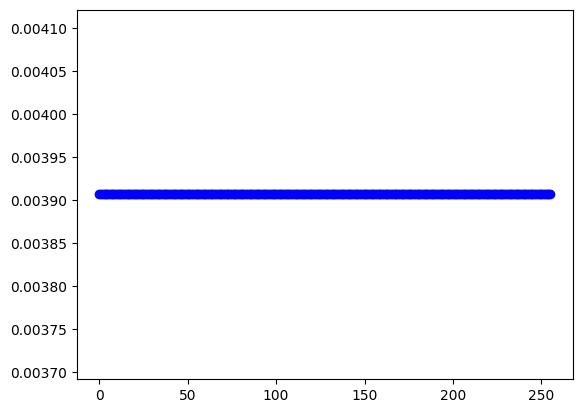

Create new register by applying mod transform to register:


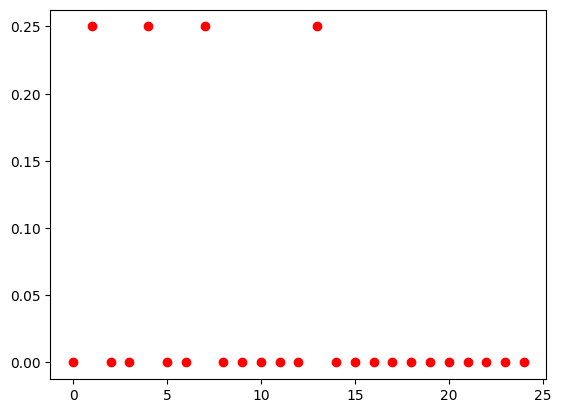

We measure this mod register. This causes its wavefunction to collapse so that only one value is possible:


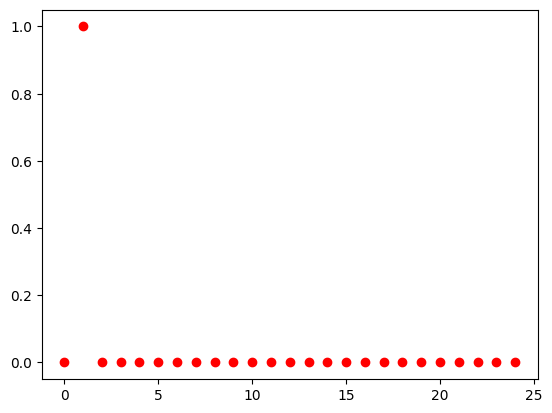

The value we got is: 1
Since the initial register is quantum entangled with the mod register, this causes it to change so that only values where x^k mod N = 1 have non-zero probability:


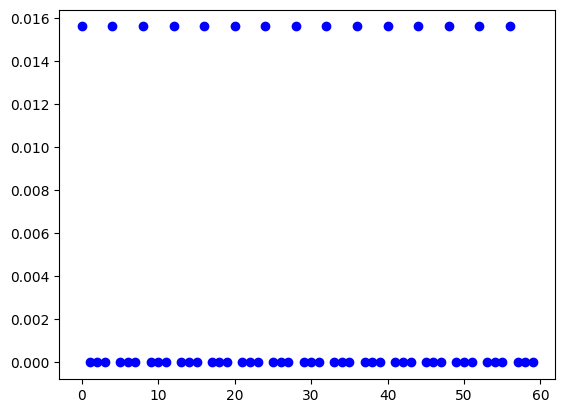

We then create a new register by applying the Fourier transform to the one above:


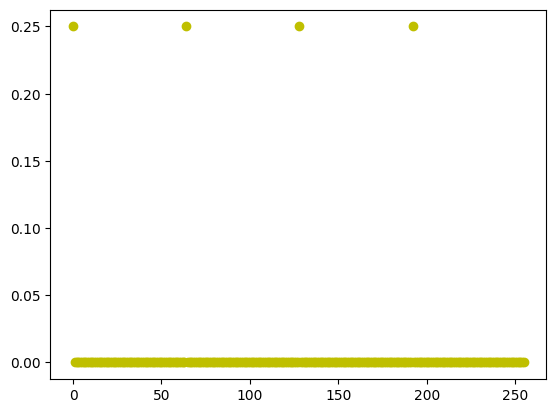

We measure a value from this, and calculate the period. This of course will collapse the waveform of the Fourier-transformed register, as shown below.
Note that if we measure 0, which is always a possibility, we'll have to try again. This simulation does that automatically.


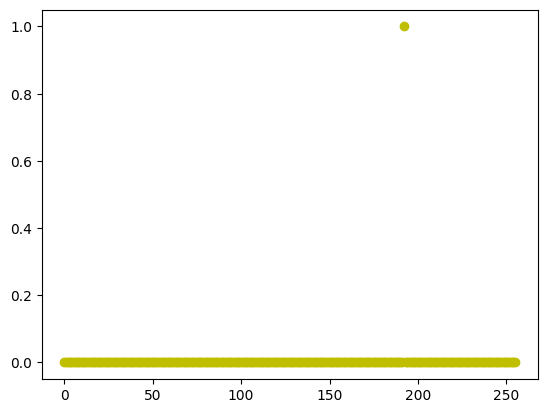

The value we measured was (by dividing the number on the register by the number of states): 0.75
The fraction closest to it is 3 / 4 with the denominator being the period.


4

In [5]:
# find r s.t. x^r mod N = 1 using quantum stuff
def quantum_period(N, x, explain=False):
    # find qubits q s.t. N^2 <= 2^q
    q      = 1
    states = 2    # specifically, states = 2^q
    while states < N**2:
        q      += 1
        states *= 2       # the reason for have states as a separate variable instead of just doing pow(q, 2) every time is it means having to multiply fewer times
                          # so is more efficient. Instead of calculating 2, 2x2, 2x2x2, 2x2x2x2 etc. it remembers the previous power and just multiplies by 2 each time

    Result = 0

    # Because qubit measurement is random, there's a chance we get 0 when we measure the final register, which means the algorithm
    # was inconclusive. So keep trying until we don't.
    while Result == 0:
        initialregister = QReg(q)
        modregister     = initialregister.modTransform(x, N)

        # We're about to change these two things forever by making quantum observations of them, so let's take two copies of the pdfs
        # which we will use to plot charts of the pdfs later
        initialregister_old = initialregister.pdf.copy()
        modregister_old     = modregister.pdf.copy()

        modResult = modregister.observe(initialregister, x, N)     # remember that they are entangled, so we have to update the original one as well!

        # Apply fourier transform
        fourierregister = initialregister.QFT()

        # Make a copy before observing s.t. we can plot it
        fourierregister_old = fourierregister.pdf.copy()

        # Now we take a reading from the register:
        Result = fourierregister.observe()         # this is k*states/r, where r is the period we want and k is a random number from 0 to r-1

        kr = Result / states        # This is k/r


    # The period is highly likely (but not certain) to be the denominator of the best rational
    # approximation to kr with denominator less than N. The fastest way to calculate this is using
    # the continued fraction algorithm until we reach a larger denominator, then stop.
    # The function below returns a list of three lists:
    # [[continued fraction representation],[numerators of convergents],[denominators of convergents]]
    CF = continued_fraction(kr, N)
    numerator   = CF[1] [-1]
    denominator = CF[2] [-1]

    # Try again if it turns out that it wasn't the period.
    # In reality, instead of this we might decide to just carry out this routine several times and
    # whichever value comes up the most has a very high probability of being the period without needing to check explicitly.
    # However, for the purposes of this simulation, this is what we will do.
    if pow(x, denominator, N) != 1:
        return quantum_period(N, x, explain)


    # Interactive explanation
    if explain == True:
        print("Initial quantum register pdf:")
        plot(initialregister_old, maxvalue=states)
        print("Create new register by applying mod transform to register:")
        plot(modregister_old, maxvalue=N+10, colour='r')

        print("We measure this mod register. This causes its wavefunction to collapse so that only one value is possible:")
        plot(modregister.pdf, maxvalue=N+10, colour='r')
        print("The value we got is:", modResult)
        print("Since the initial register is quantum entangled with the mod register, this causes it to change so that only values where x^k mod N =", modResult, "have non-zero probability:")
        plot(initialregister.pdf, maxvalue=N*4)

        print("We then create a new register by applying the Fourier transform to the one above:")
        plot(fourierregister_old, maxvalue=states, colour='y')
        print("We measure a value from this, and calculate the period. This of course will collapse the waveform of the Fourier-transformed register, as shown below.")
        print("Note that if we measure 0, which is always a possibility, we'll have to try again. This simulation does that automatically.")
        plot(fourierregister.pdf, maxvalue=states, colour='y')

        print("The value we measured was (by dividing the number on the register by the number of states):", kr)
        print("The fraction closest to it is", numerator, "/", denominator, "with the denominator being the period.")

    return denominator



# Generate [[continued fraction expansion],[numerators of convergents],[denominators of convergents]]
# Theory behind this can be read about at https://brilliant.org/wiki/continued-fractions/
# We covered the expansion bit in Foundations (though not the stuff on convergents)
# Note that this might not be perfect for very long decimals due to floating point rounding issues
# (I used a tolerance of 10^-8 to check whether values are 0) but for our purposes, this should be ok.
def continued_fraction(N, maxdenominator):
    current = N
    expansion = []

    # Counter for our current position
    i = 0
    # Lists of numerators and denominators of convergents
    nums = []
    dens = []

    while True:
        # Calculate the next part of the expansion
        expansion.append(int(np.floor(current)))

        # Calculate the numerator and denominator of the convergent
        if i == 0:
            nextnum = int(np.floor(N))
            nextden =  1
        elif i == 1:
            nextnum = expansion[i] * nums[i-1] + 1
            nextden = expansion[i] * dens[i-1]
        else:
            nextnum = expansion[i] * nums[i-1] + nums[i-2]
            nextden = expansion[i] * dens[i-1] + dens[i-2]

        # Stop immediately if we have surpassed our limit on the maximum denominator
        if nextden >= maxdenominator:
                break
        else:
            nums.append(nextnum)
            dens.append(nextden)

        # Update our current number for the next round. Break if the next entry is going to be 0
        # (due to floating point rounding errors, we use a small tolerance)
        if current % 1.0 <= 10**(-8):
            break
        else:
            current = 1/(current % 1.0)

        # Increment counter by 1
        i += 1

    return [expansion, nums, dens]


quantum_period(15,7, explain=True)